In [3]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [23]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.models import Sequential

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape,y_train.shape

((60000, 28, 28), (60000,))

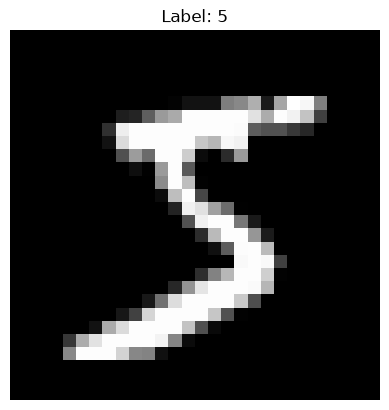

In [24]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

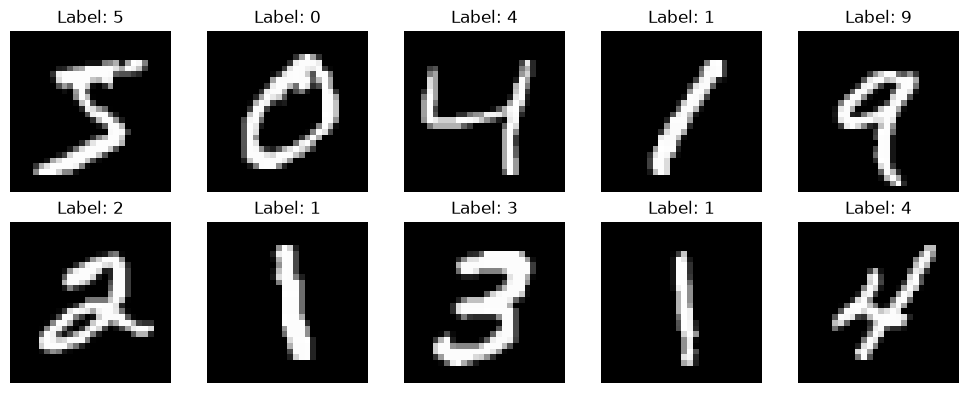

In [25]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i],cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()    
plt.show()
    

In [26]:
X_train = X_train/255.0
X_test = X_test/255.0

In [27]:
X_train.min(),X_train.max()

(np.float64(0.0), np.float64(1.0))

In [29]:
model = Sequential([
    Flatten(input_shape= (28,28)),
    Dense(128, activation = "relu"),
    Dense(10, activation = "softmax")
])

In [30]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [32]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)
    

In [34]:
y_train[0:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

In [35]:
history = model.fit(X_train, y_train, epochs = 5,validation_split = 0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 840us/step - accuracy: 0.9214 - loss: 0.2755 - val_accuracy: 0.9630 - val_loss: 0.1337
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 798us/step - accuracy: 0.9636 - loss: 0.1221 - val_accuracy: 0.9725 - val_loss: 0.0947
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 793us/step - accuracy: 0.9749 - loss: 0.0827 - val_accuracy: 0.9755 - val_loss: 0.0893
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 807us/step - accuracy: 0.9814 - loss: 0.0613 - val_accuracy: 0.9742 - val_loss: 0.0851
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 798us/step - accuracy: 0.9856 - loss: 0.0466 - val_accuracy: 0.9777 - val_loss: 0.0769


In [36]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 395us/step - accuracy: 0.9774 - loss: 0.0731
Test Loss: 0.07310053706169128
Test Accuracy: 0.977400004863739


In [37]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


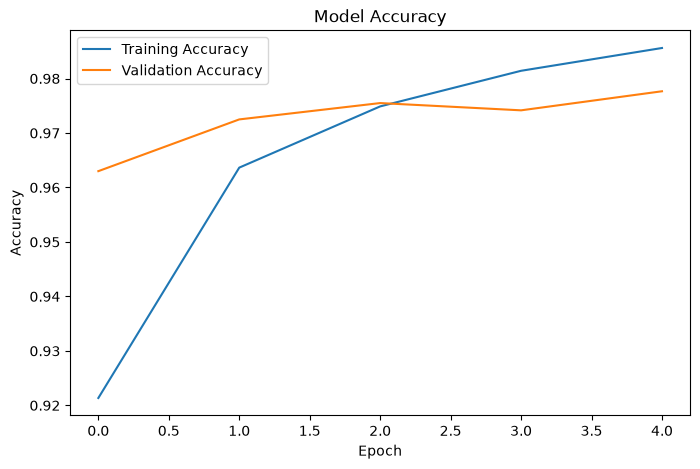

In [38]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

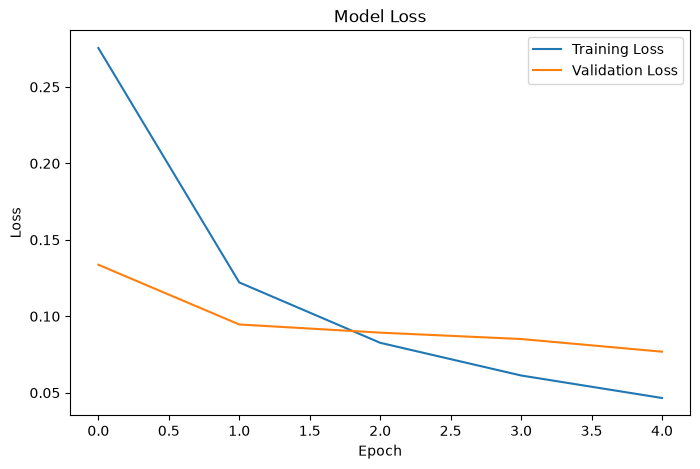

In [39]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [40]:
predictions = model.predict(X_test)
predictions.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 324us/step


(10000, 10)

In [42]:
predicted_label= np.argmax(predictions[0])
predicted_label, predictions[0]

(np.int64(7),
 array([9.33569222e-09, 5.58368640e-08, 5.02948205e-06, 4.62607801e-04,
        6.02640507e-12, 1.15289254e-07, 8.77497554e-12, 9.99524117e-01,
        5.70442694e-07, 7.55970768e-06], dtype=float32))

<function matplotlib.pyplot.show(close=None, block=None)>

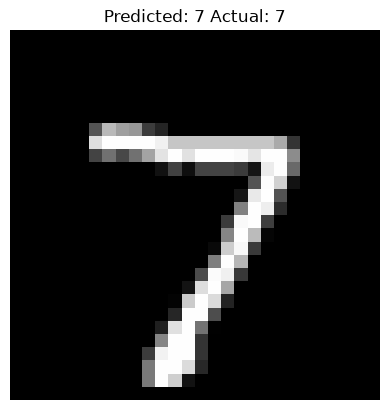

In [45]:
plt.imshow(X_test[0], cmap = "gray")
plt.title(f"Predicted: {predicted_label} Actual: {y_test[0]}")
plt.axis("off")
plt.show

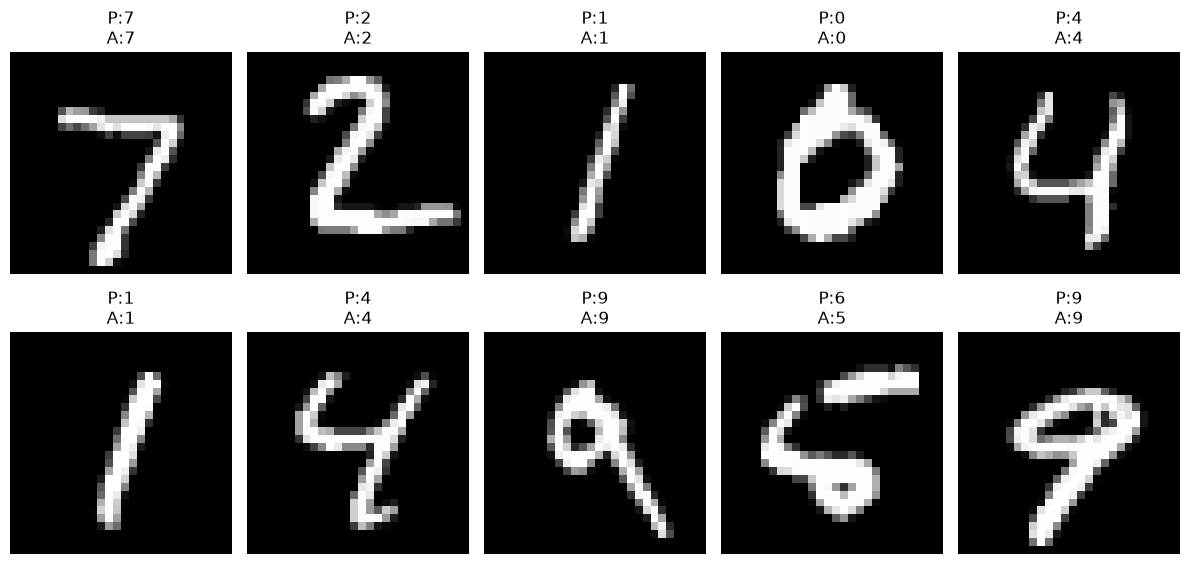

In [46]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i], cmap="gray")

    predicted = np.argmax(predictions[i])

    plt.title(f"P:{predicted}\nA:{y_test[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()